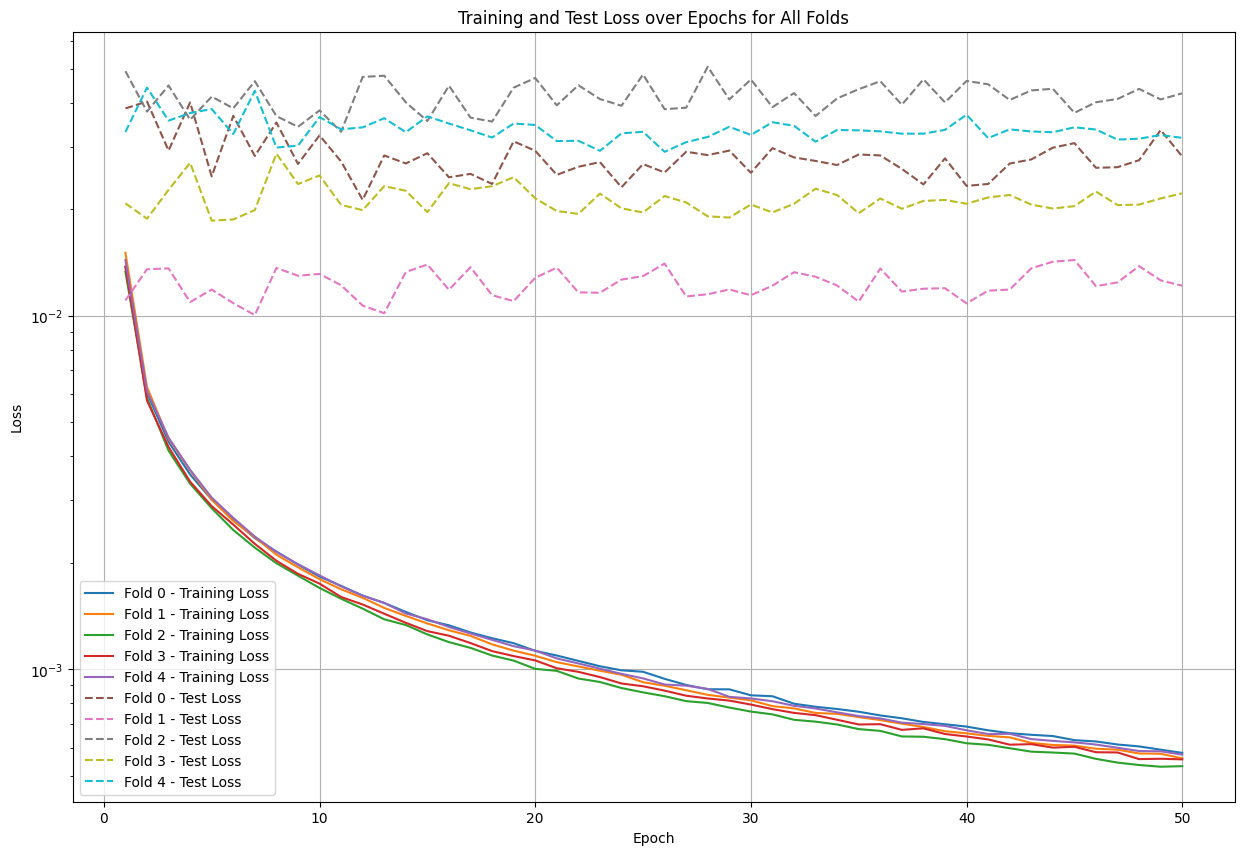

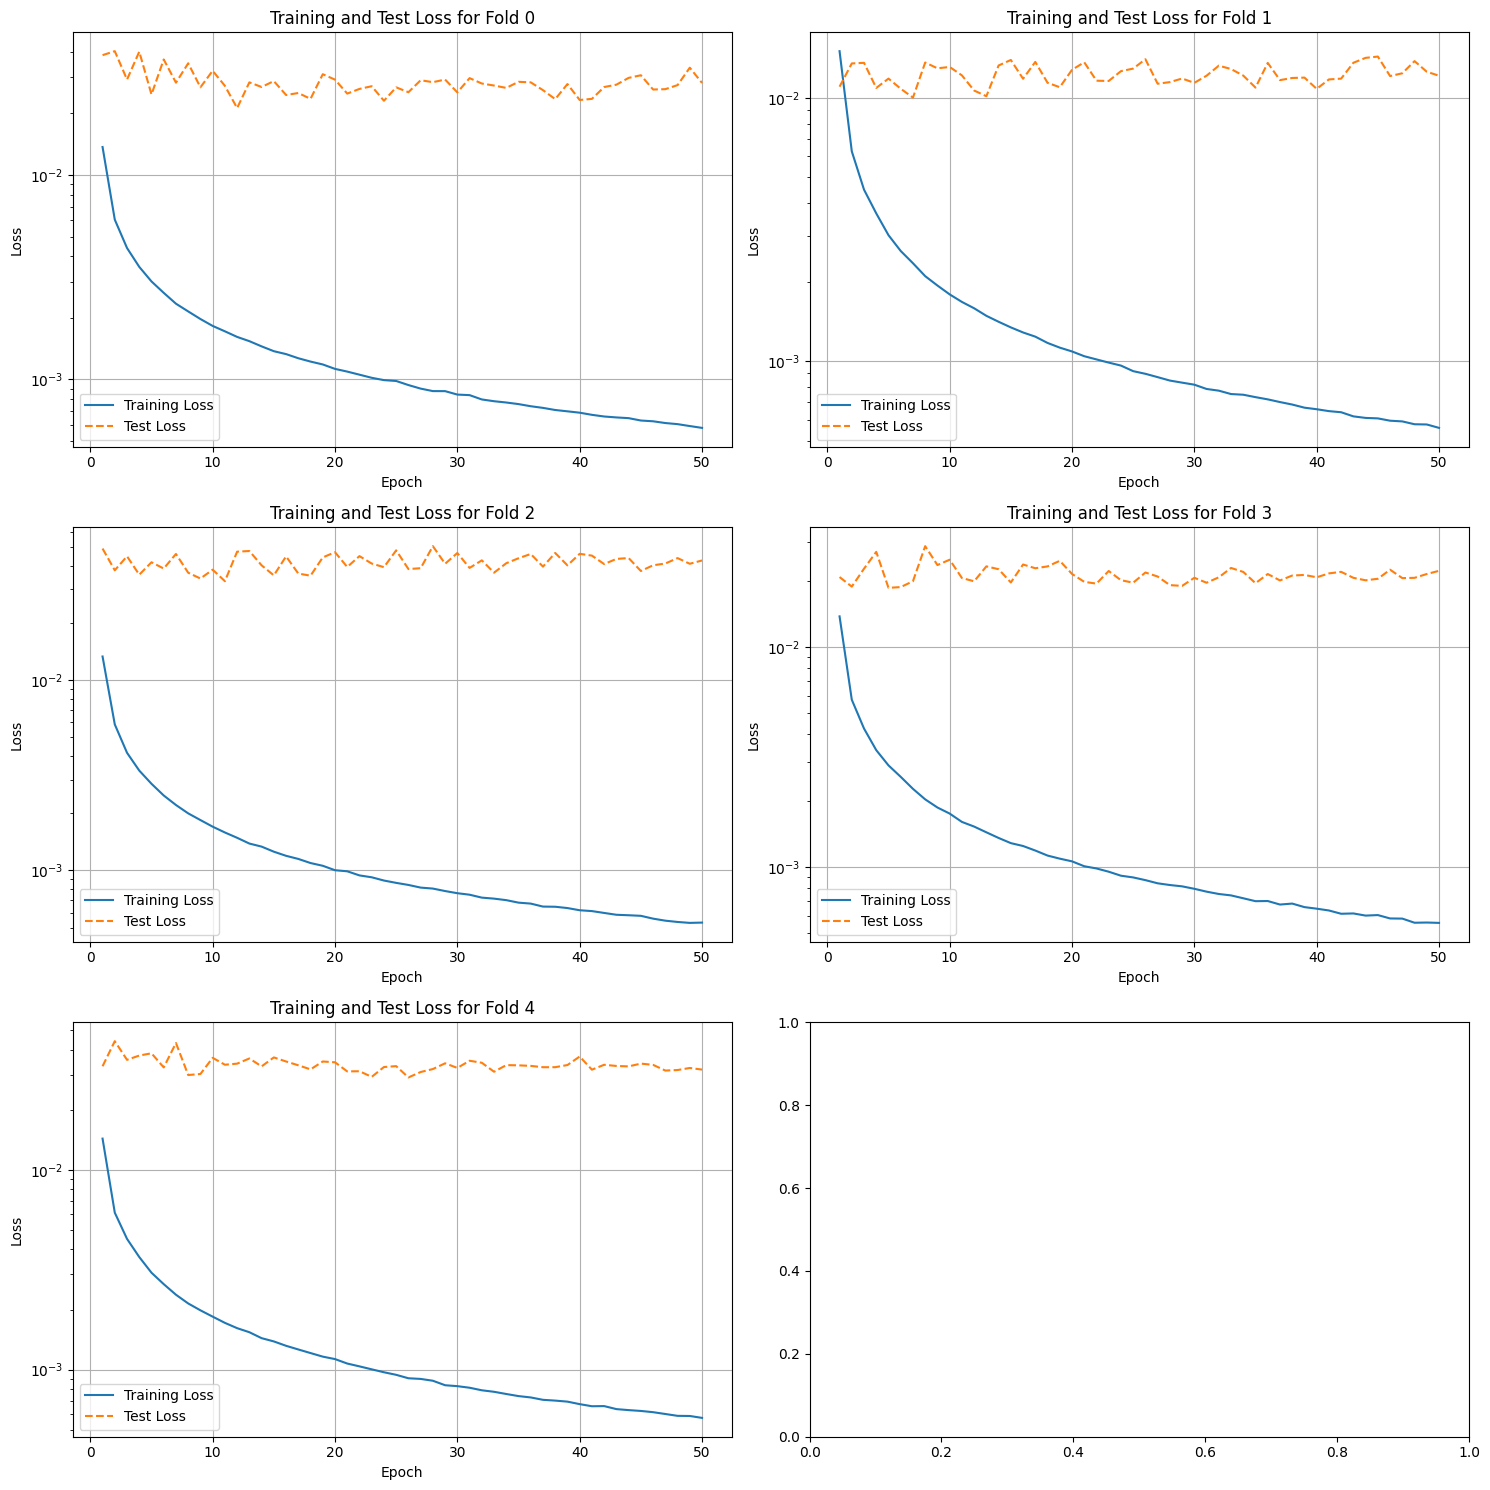

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to parse log files
def parse_log_file(file_path, fold):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    epochs = []
    train_loss = []
    test_loss = []

    for i in range(0, len(lines), 2):
        test_line = lines[i].split(':')
        train_line = lines[i + 1].split(':')
        
        epochs.append(int(train_line[-2].split(',')[0].split()[-1]))
        test_loss.append(float(test_line[-1]))
        train_loss.append(float(train_line[-1]))

    return pd.DataFrame({
        'Epoch': epochs,
        'Train Loss': train_loss,
        'Test Loss': test_loss,
        'Fold': fold
    })

# Initialize a list to store dataframes for all folds
dfs = []

# Number of folds
num_folds = 5

# Parse log files for all folds
for fold in range(num_folds):
    df = parse_log_file(f'my_scripts/trained_resnet_with_fold_{fold}/loss.log', fold)
    dfs.append(df)

# Combine all dataframes
df_all = pd.concat(dfs, ignore_index=True)

# Create the combined plot for all folds
plt.figure(figsize=(15, 10))

# Plot Train Loss for all folds
for fold in range(num_folds):
    df_fold = df_all[df_all['Fold'] == fold]
    plt.plot(df_fold['Epoch'], df_fold['Train Loss'], label=f'Fold {fold} - Training Loss')

# Plot Test Loss for all folds
for fold in range(num_folds):
    df_fold = df_all[df_all['Fold'] == fold]
    plt.plot(df_fold['Epoch'], df_fold['Test Loss'], linestyle='--', label=f'Fold {fold} - Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs for All Folds')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

# Create a grid of 3x2 for individual plots
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
axs = axs.flatten()  # Flatten the 2D array of axes for easy iteration

# Create individual plots for each fold
for fold in range(num_folds):
    df_fold = df_all[df_all['Fold'] == fold]
    
    axs[fold].plot(df_fold['Epoch'], df_fold['Train Loss'], label='Training Loss')
    axs[fold].plot(df_fold['Epoch'], df_fold['Test Loss'], linestyle='--', label='Test Loss')
    axs[fold].set_title(f'Training and Test Loss for Fold {fold}')
    axs[fold].set_xlabel('Epoch')
    axs[fold].set_ylabel('Loss')
    axs[fold].legend()
    axs[fold].set_yscale('log')
    axs[fold].grid()

# Adjust layout
plt.tight_layout()
plt.show()



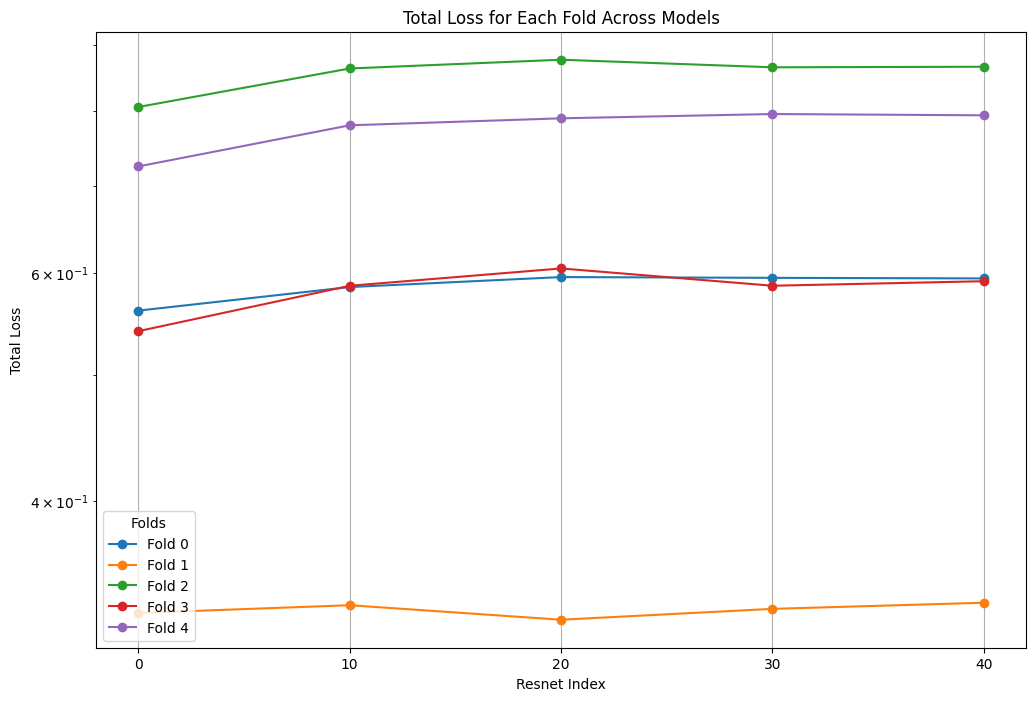

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Initialize lists to store the data
folds = []
models = []
losses = []

# Read the loss results from the text file
with open('loss_results.txt', 'r') as file:
    for line in file:
        # Split the line to extract fold, model, and loss
        parts = line.strip().split(':')
        if len(parts) == 2:
            # Extract fold and model number
            fold_model = parts[0].split(',')
            fold = int(fold_model[0].split(' ')[-1])  # Get the fold number
            model = int(fold_model[1].split(' ')[-1])  # Get the model number
            loss = float(parts[1].strip())  # Get the loss value
            
            # Append to lists
            folds.append(fold)
            models.append(model)
            losses.append(loss)

# Create a DataFrame from the lists
loss_results = pd.DataFrame({
    'Fold': folds,
    'Model': models,
    'Loss': losses
})

# Create a pivot table for easier plotting
pivot_table = loss_results.pivot(index='Model', columns='Fold', values='Loss')

# Plotting
plt.figure(figsize=(12, 8))
for fold in pivot_table.columns:
    plt.plot(pivot_table.index, pivot_table[fold], marker='o', label=f'Fold {fold}')

plt.title('Total Loss for Each Fold Across Models')
plt.xlabel('Resnet Index')
plt.ylabel('Total Loss')
plt.xticks(pivot_table.index)  # Set x-ticks to model indices
plt.legend(title='Folds')
plt.grid()
plt.yscale('log')  # Use log scale for better visualization of loss differences
plt.show()

In [28]:
import pandas as pd

# Initialize lists to store the data
folds = []
models = []
losses = []

# Read the loss results from the text file
with open('loss_results.txt', 'r') as file:
    for line in file:
        # Split the line to extract fold, model, and loss
        parts = line.strip().split(':')
        if len(parts) == 2:
            # Extract fold and model number
            fold_model = parts[0].split(',')
            fold = int(fold_model[0].split(' ')[-1])  # Get the fold number
            model = int(fold_model[1].split(' ')[-1])  # Get the model number
            loss = float(parts[1].strip())  # Get the loss value
            
            # Append to lists
            folds.append(fold)
            models.append(model)
            losses.append(loss)

# Create a DataFrame from the lists
loss_results = pd.DataFrame({
    'Fold': folds,
    'Resnet': models,
    'Loss': losses
})

# Display the DataFrame as a table
print("Loss Results Table:")
print(loss_results)

Loss Results Table:
    Fold  Resnet      Loss
0      0       0  0.561002
1      0      10  0.584997
2      0      20  0.595487
3      0      30  0.594668
4      0      40  0.594067
5      1       0  0.327657
6      1      10  0.332215
7      1      20  0.323755
8      1      30  0.330064
9      1      40  0.333684
10     2       0  0.805816
11     2      10  0.862954
12     2      20  0.876496
13     2      30  0.864771
14     2      40  0.865606
15     3       0  0.540880
16     3      10  0.586332
17     3      20  0.604679
18     3      30  0.586387
19     3      40  0.591122
20     4       0  0.724987
21     4      10  0.779992
22     4      20  0.789753
23     4      30  0.795809
24     4      40  0.793986


In [30]:
import pandas as pd

# Initialize lists to store the data
folds = []
models = []
losses = []

# Read the best models from the text file
with open('best_models.txt', 'r') as file:
    for line in file:
        # Split the line to extract fold, model, and loss
        parts = line.strip().split(':')
        if len(parts) == 2:
            # Extract fold and model number
            fold_model = parts[0].split(',')
            fold = int(fold_model[0].split(' ')[-1])  # Get the fold number
            model = int(fold_model[1].split(' ')[-1])  # Get the model number
            loss = float(parts[1].strip())  # Get the loss value
            
            # Append to lists
            folds.append(fold)
            models.append(model)
            losses.append(loss)

# Create a DataFrame from the lists
best_models = pd.DataFrame({
    'Fold': folds,
    'Model': models,
    'Loss': losses
})

# Calculate the average loss
average_loss = best_models['Loss'].mean()

# Display the average loss
print(f"Average Loss from Best Models: {average_loss}")


Average Loss from Best Models: 0.6399787203180887
